BIAS VARIANCE TRADE OFF THEN UNDERFITTING , OVERFITTING & GOOD FIT 

In [5]:
# import required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [6]:
#Step-1 : Create a non-linear dataset
np.random.seed(0) #FOR REPRODUCABILITY

#CREATE X Values from-3 to 3
X = np.linspace(-3, 3, 100).reshape(-1, 1)
print(X)

#this creates curved (non-linear)data

y = X**2 + np.random.normal(0, 1, size = X.shape)#True function is y = x^2 + noise
print(y)

#split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.2)

[[-3.        ]
 [-2.93939394]
 [-2.87878788]
 [-2.81818182]
 [-2.75757576]
 [-2.6969697 ]
 [-2.63636364]
 [-2.57575758]
 [-2.51515152]
 [-2.45454545]
 [-2.39393939]
 [-2.33333333]
 [-2.27272727]
 [-2.21212121]
 [-2.15151515]
 [-2.09090909]
 [-2.03030303]
 [-1.96969697]
 [-1.90909091]
 [-1.84848485]
 [-1.78787879]
 [-1.72727273]
 [-1.66666667]
 [-1.60606061]
 [-1.54545455]
 [-1.48484848]
 [-1.42424242]
 [-1.36363636]
 [-1.3030303 ]
 [-1.24242424]
 [-1.18181818]
 [-1.12121212]
 [-1.06060606]
 [-1.        ]
 [-0.93939394]
 [-0.87878788]
 [-0.81818182]
 [-0.75757576]
 [-0.6969697 ]
 [-0.63636364]
 [-0.57575758]
 [-0.51515152]
 [-0.45454545]
 [-0.39393939]
 [-0.33333333]
 [-0.27272727]
 [-0.21212121]
 [-0.15151515]
 [-0.09090909]
 [-0.03030303]
 [ 0.03030303]
 [ 0.09090909]
 [ 0.15151515]
 [ 0.21212121]
 [ 0.27272727]
 [ 0.33333333]
 [ 0.39393939]
 [ 0.45454545]
 [ 0.51515152]
 [ 0.57575758]
 [ 0.63636364]
 [ 0.6969697 ]
 [ 0.75757576]
 [ 0.81818182]
 [ 0.87878788]
 [ 0.93939394]
 [ 1.     

In [7]:
#step 2: Function to Train model of any degree

def train_model(degree):

#This function converts data into polynomial features
#rains a regression model
#calculate training and testing error



#converst x into polynomial features

  poly = PolynomialFeatures(degree)
  X_poly_train = poly.fit_transform(X_train)
  X_poly_test= poly.transform(X_test)

# train lineaqr regression model
  model = LinearRegression()
  model.fit(X_poly_train, y_train)

#predict on training and testing data
  y_train_pred = model.predict(X_poly_train)
  y_test_pred = model.predict(X_poly_test)

#calculate Mean squared error

  train_error= mean_squared_error(y_train, y_train_pred)
  test_error = mean_squared_error(y_test, y_test_pred)


  return model, poly, train_error, test_error

In [10]:
#step 3: Train Three Models

#underfitting model(too simple)
model1, poly1,train_err1, test_err1 = train_model(1)

# Good fit Model
model2, poly2, train_err2, test_err2 = train_model(2)

# Overfitting Model
model3, poly3, train_err3, test_err3 = train_model(10)

In [11]:
#step 4 Print Errors

print("UNDERFITTING MODEL (Degree = 1)")
print("Training Error:", train_err1)
print("Testing Error:", test_err1)

print("\nGood FIT MODEL (Degree = 2)")
print("TRAINING ERROR:", train_err2)
print("TESTING ERROR:", test_err2)


print("\nOVERFITTING MODEL (Degree = 10)")
print("TRAINING ERROR:", train_err3)
print("TESTING ERROR:" , test_err3)


UNDERFITTING MODEL (Degree = 1)
Training Error: 10.697227365550955
Testing Error: 10.738760281381255

Good FIT MODEL (Degree = 2)
TRAINING ERROR: 0.9120999115412248
TESTING ERROR: 0.632501917117202

OVERFITTING MODEL (Degree = 10)
TRAINING ERROR: 0.8908502108013095
TESTING ERROR: 0.7025367368901694


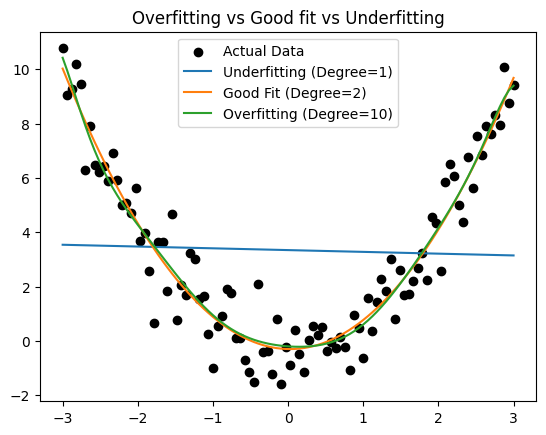

In [12]:
#step 5: Plot Prediction

plt.scatter(X, y, color = "black", label="Actual Data")
X_plot = np.linspace(-3, 3, 100).reshape(-1, 1)

# Plot Underfitting Curve
y_plot1 = model1.predict(poly1.transform(X_plot))
plt.plot(X_plot, y_plot1, label = "Underfitting (Degree=1)")

#Plot Good fit Curve
y_plot2 = model2.predict(poly2.transform(X_plot))
plt.plot(X_plot, y_plot2, label = "Good Fit (Degree=2)")

#plot overfitting curve
y_plot3 = model3.predict(poly3.transform(X_plot))
plt.plot(X_plot, y_plot3, label = "Overfitting (Degree=10)")

plt.legend()
plt.title("Overfitting vs Good fit vs Underfitting")
plt.show()

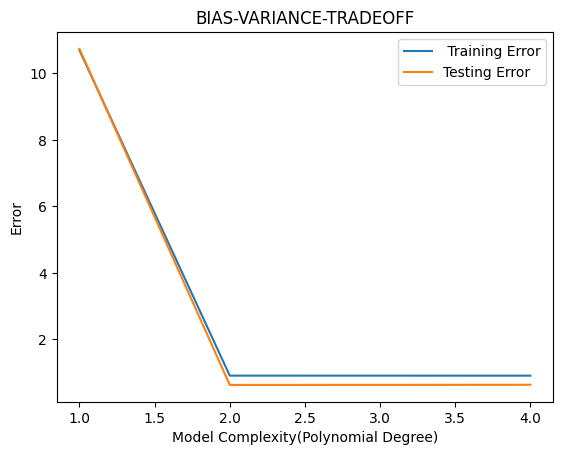

In [13]:
#step 6: Bias-Variance Trade-off curve

degree = range(1,5)
train_errors = []
test_errors = []

for d in degree:
  _, _, train_err, test_err = train_model(d) #_,_,  this underscore is using for Ignoring. after that train error and test error are there only that i need so thats why its ignoring
  train_errors.append(train_err)
  test_errors.append(test_err)

plt.plot(degree, train_errors, label =" Training Error")
plt.plot(degree, test_errors, label = "Testing Error")
plt.xlabel("Model Complexity(Polynomial Degree)")
plt.ylabel("Error")
plt.legend()
plt.title("BIAS-VARIANCE-TRADEOFF")
plt.show()
